# 03 — Learning Curves

Visualise data efficiency results from `results/{task}/data_efficiency/results.csv`:

- AUROC and F1 vs training set fraction
- Comparison across architectures and pre-training strategies
- Confidence bands from multiple seeds
- Side-by-side ulcer vs MES comparison

Run **after** executing `scripts/ulcer/run_data_efficiency.py` and/or `scripts/mes/run_data_efficiency.py`.

In [18]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path("..")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 120

## Configuration

In [19]:
ULCER_RESULTS = ROOT / "results/ulcer/data_efficiency/results.csv"
ULCER_RAW     = ROOT / "results/ulcer/data_efficiency/results_per_seed.csv"

MES_RESULTS   = ROOT / "results/mes/data_efficiency/results.csv"
MES_RAW       = ROOT / "results/mes/data_efficiency/results_per_seed.csv"

## Filtering plot

In [35]:
# Metrics to plot
METRICS = ["auroc", "f1"]

# Head types to include (None = all)
HEAD_FILTER = ["linear"]

# Models to include (None = all)
MODEL_FILTER: list[str] | None = [
    "resnet50_imagenet",
    "resnet50_5M",
    "resnet50_1M",
    "resnet50_200K"
]
# MODEL_FILTER = ["vits16_imagenet", "efficientnetb0"]

## 1. Load Results

In [33]:
def load_results(path: Path, label: str) -> pd.DataFrame | None:
    if not path.exists():
        print(f"[{label}] Results file not found: {path}")
        return None
    df = pd.read_csv(path)
    print(f"[{label}] {len(df)} rows | models: {df['model'].unique().tolist()}")
    return df

df_ulcer = load_results(ULCER_RESULTS, "ULCER")
df_mes   = load_results(MES_RESULTS,   "MES")

[ULCER] 35 rows | models: ['efficientnetb0', 'resnet50_1M', 'resnet50_200K', 'resnet50_5M', 'resnet50_imagenet', 'vits16_gastronet', 'vits16_imagenet']
[MES] 35 rows | models: ['efficientnetb0', 'resnet50_1M', 'resnet50_200K', 'resnet50_5M', 'resnet50_imagenet', 'vits16_gastronet', 'vits16_imagenet']


## 2. Single-Task Learning Curves

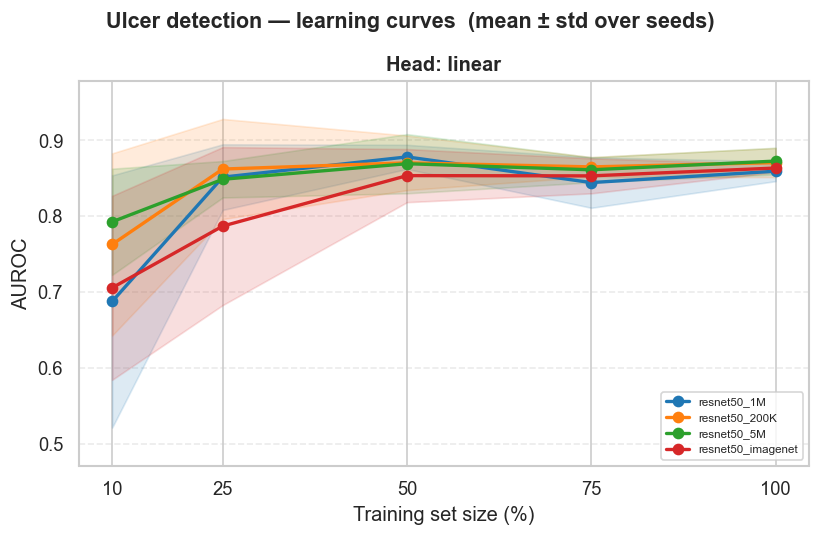

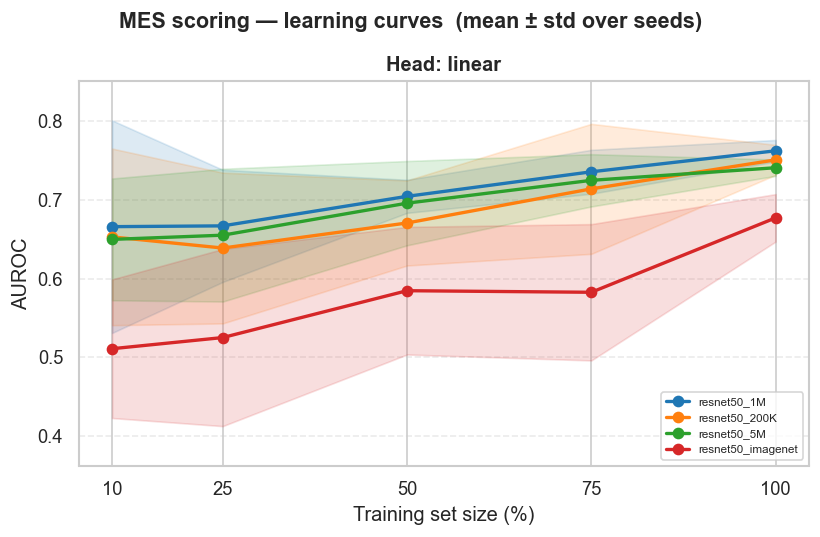

In [36]:
def plot_learning_curves_rich(
    df: pd.DataFrame,
    task: str,
    metrics: list[str] = ("auroc", "f1"),
    head_filter: list[str] | None = None,
    model_filter: list[str] | None = None,
    palette: str = "tab10",
) -> None:
    if df is None:
        return

    if head_filter:
        df = df[df["head_type"].isin(head_filter)]
    if model_filter:
        df = df[df["model"].isin(model_filter)]
    if df.empty:
        print(f"[{task}] No data after filtering.")
        return

    head_types = df["head_type"].unique()
    n_metrics  = len(metrics)
    ncols      = min(len(head_types), 2)
    nrows      = n_metrics * ((len(head_types) + ncols - 1) // ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(7 * ncols, 4 * nrows),
        sharey="row", squeeze=False,
    )
    fig.suptitle(
        f"{task} — learning curves  (mean ± std over seeds)",
        fontsize=13, fontweight="bold",
    )

    colors    = plt.get_cmap(palette).colors
    models    = df["model"].unique()
    color_map = {m: colors[i % len(colors)] for i, m in enumerate(models)}

    heads_per_row = ncols
    y_up = []
    y_down = []
    for m_idx, metric in enumerate(metrics):
        mean_col = f"{metric}_mean"
        std_col  = f"{metric}_std"
        if mean_col not in df.columns:
            print(f"Column '{mean_col}' not found — skipping '{metric}'")
            continue

        for h_idx, head in enumerate(head_types):
            row = m_idx * ((len(head_types) + heads_per_row - 1) // heads_per_row) + h_idx // heads_per_row
            col = h_idx % heads_per_row
            ax  = axes[row][col]
            sub = df[df["head_type"] == head]

            for model_name, grp in sub.groupby("model"):
                grp   = grp.sort_values("subset_ratio")
                x     = grp["subset_ratio"] * 100
                y     = grp[mean_col]
                y_std = grp[std_col] if std_col in grp.columns else 0
                y_up.append((y + y_std).max())
                y_down.append((y - y_std).min())
                color = color_map[model_name]
                ax.plot(x, y, marker="o", label=model_name, linewidth=2, color=color)
                ax.fill_between(x, y - y_std, y + y_std, color=color, alpha=0.15)

            ax.set_title(f"Head: {head}" if m_idx == 0 else "", fontweight="bold")
            ax.set_xlabel("Training set size (%)")
            ax.set_ylabel(metric.upper() if col == 0 else "")
            ax.set_xticks([10, 25, 50, 75, 100])
            ax.set_ylim(min(y_down) - 0.05, max(y_up) + 0.05)
            ax.grid(axis="y", linestyle="--", alpha=0.4)
            ax.legend(loc="lower right", fontsize=7, frameon=True)

    for idx in range(len(head_types), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.tight_layout()
    plt.show()

plot_learning_curves_rich(df_ulcer, "Ulcer detection", METRICS, HEAD_FILTER, MODEL_FILTER)
plot_learning_curves_rich(df_mes,   "MES scoring",     METRICS, HEAD_FILTER, MODEL_FILTER)

## 3. Per-Seed Raw Results

Each dot = one independent run (seed × ratio). No lines — runs at different ratios share no data.

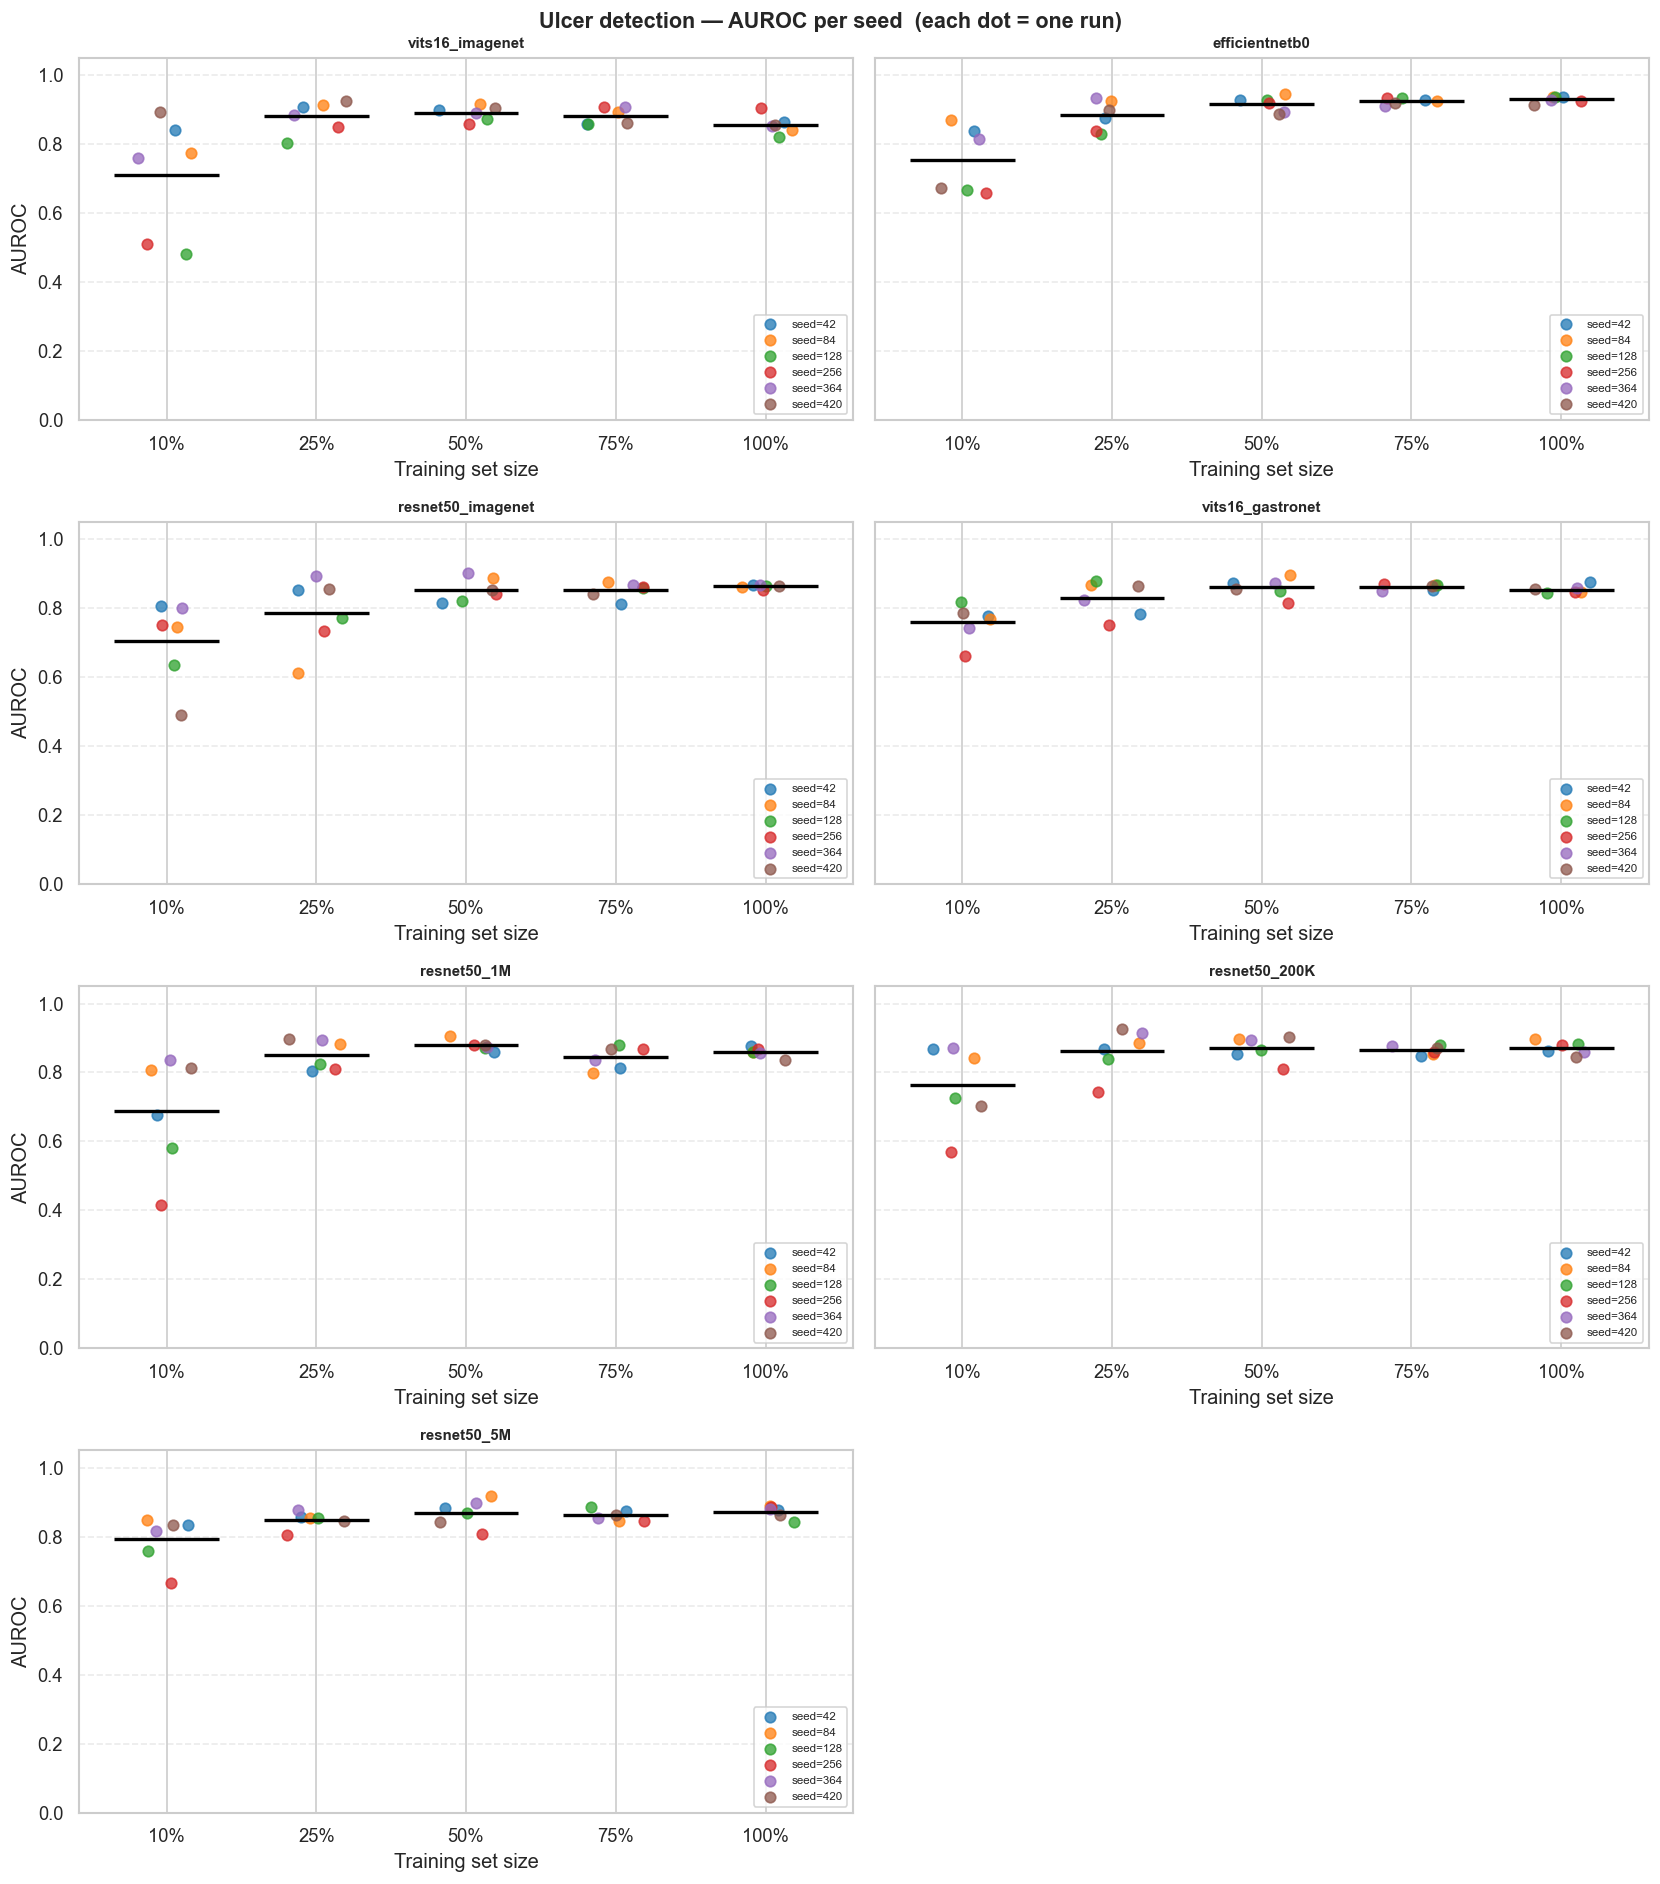

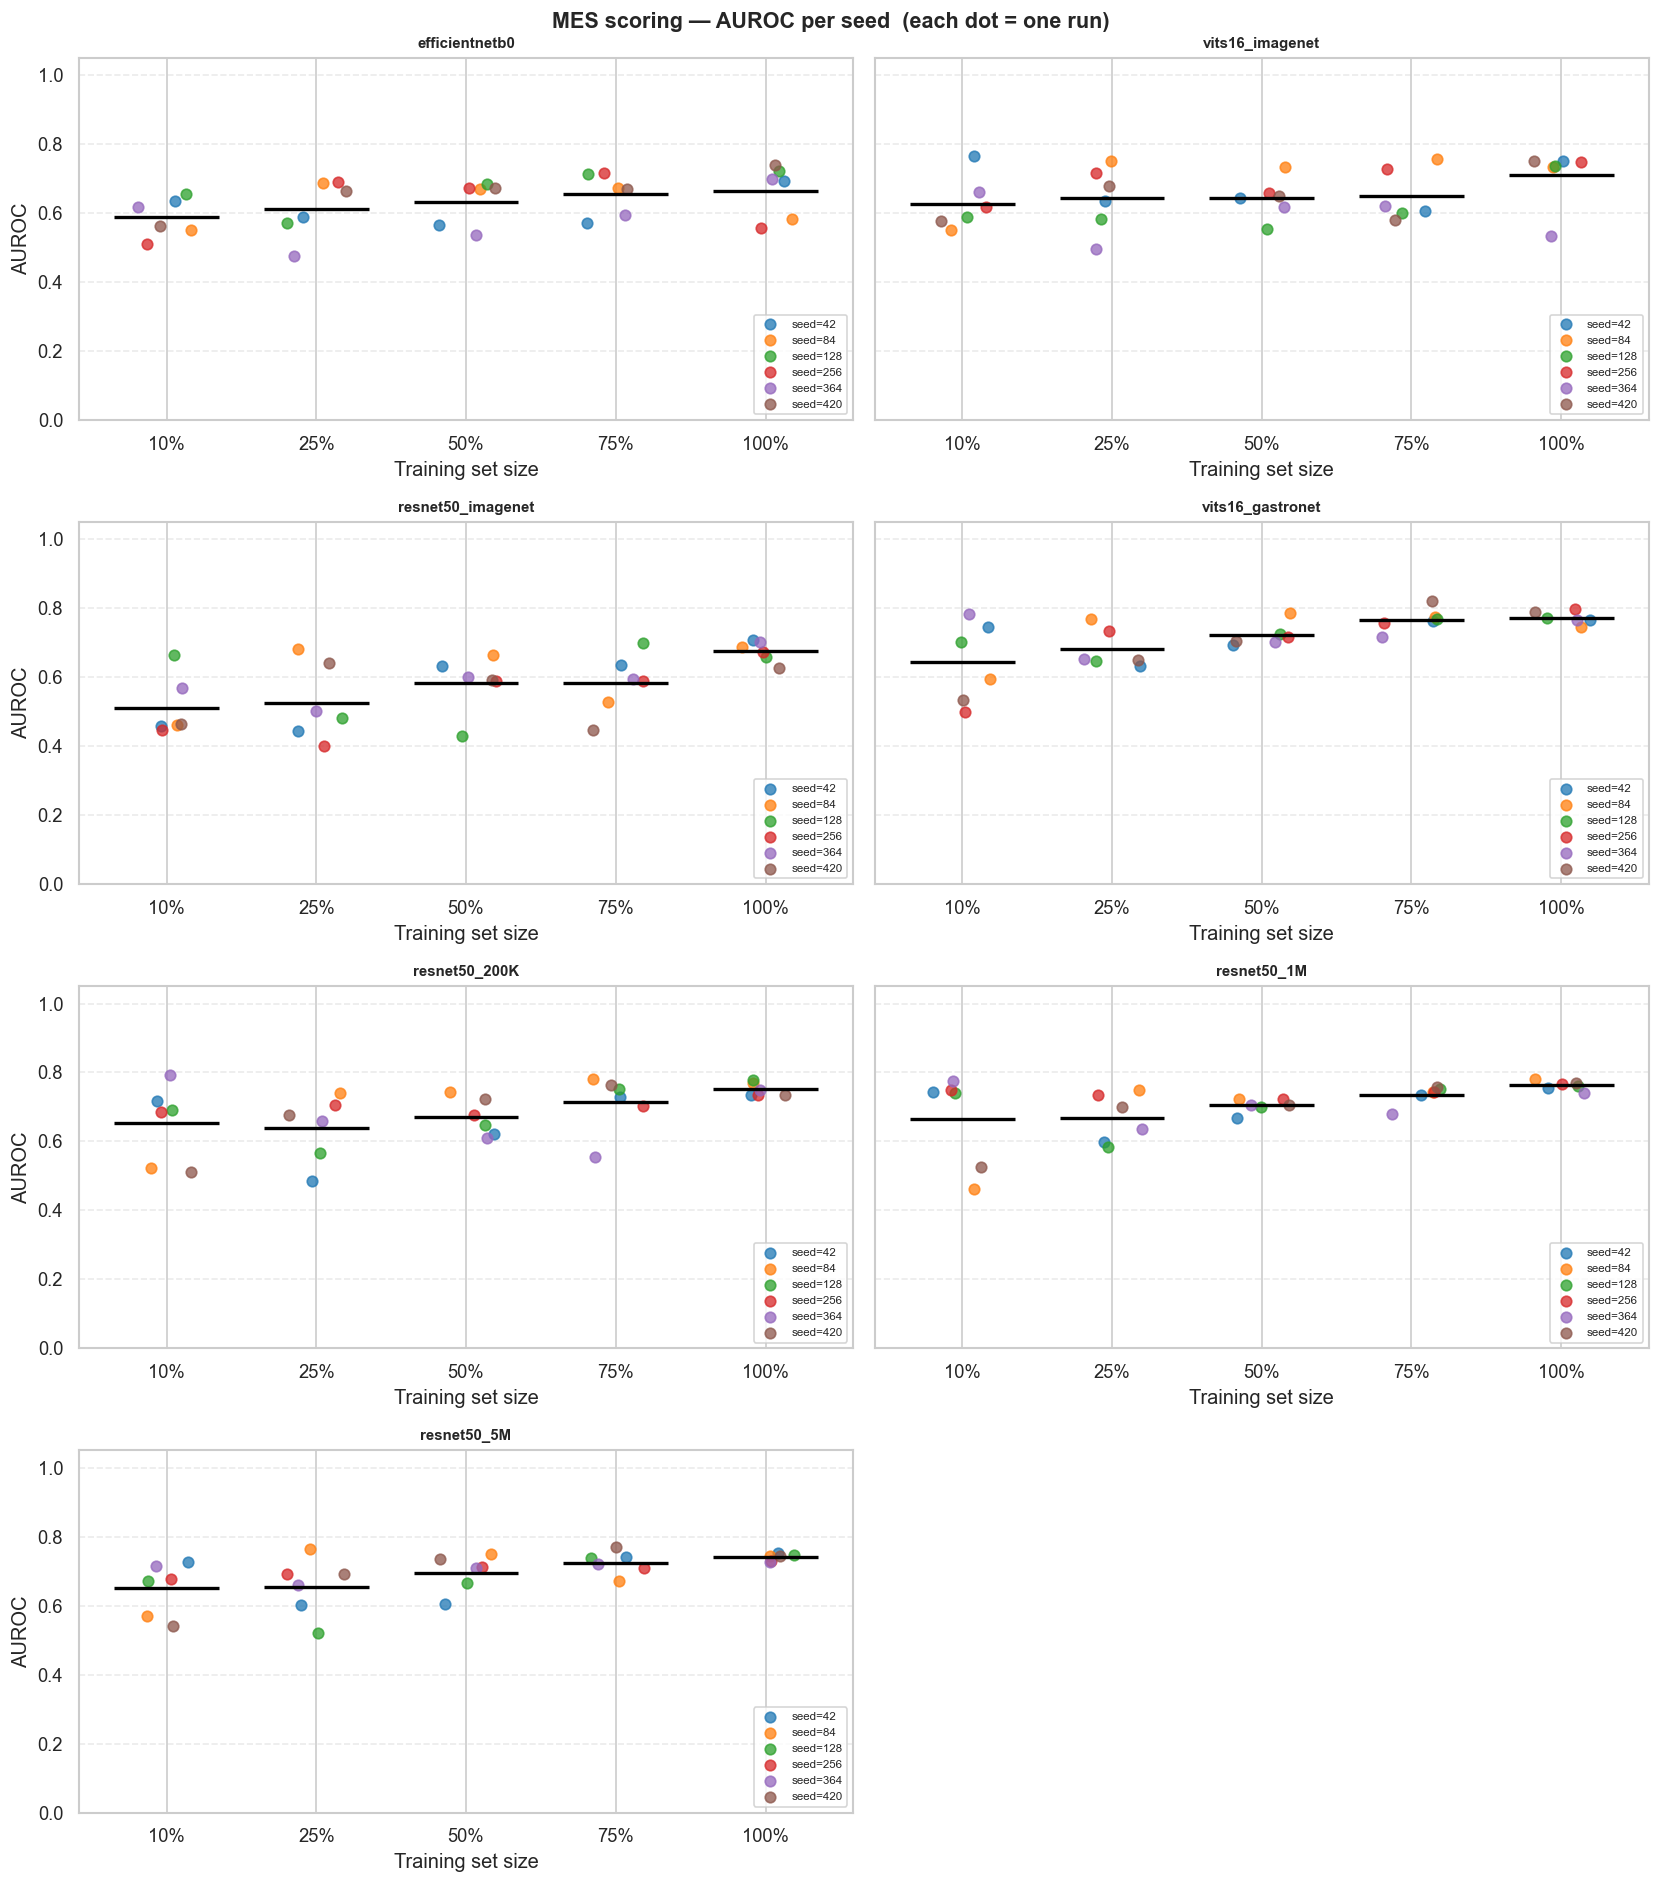

In [23]:
def plot_per_seed_dots(
    path: Path,
    task: str,
    metric: str = "auroc",
    head_filter: list[str] | None = None,
    model_filter: list[str] | None = None,
    jitter: float = 0.8,
) -> None:
    """Strip plot of per-seed results.

    Each dot is one independent run. A horizontal bar marks the mean at each ratio.
    """
    if not path.exists():
        print(f"[{task}] Per-seed file not found: {path}")
        return

    df = pd.read_csv(path)
    if head_filter:
        df = df[df["head_type"].isin(head_filter)]
    if model_filter:
        df = df[df["model"].isin(model_filter)]
    if df.empty:
        print(f"[{task}] No data after filtering.")
        return

    models = df["model"].unique()
    ncols  = min(len(models), 2)
    nrows  = (len(models) + ncols - 1) // ncols
    rng    = __import__("numpy").random.default_rng(0)

    fig, axes = plt.subplots(
        nrows, ncols, figsize=(7 * ncols, 4 * nrows), sharey=True, squeeze=False
    )
    fig.suptitle(
        f"{task} — {metric.upper()} per seed  (each dot = one run)",
        fontsize=13, fontweight="bold",
    )

    colors    = plt.get_cmap("tab10").colors
    seeds     = sorted(df["seed"].unique())
    color_map = {s: colors[i % len(colors)] for i, s in enumerate(seeds)}

    for idx, model_name in enumerate(models):
        ax  = axes[idx // ncols][idx % ncols]
        mdf = df[df["model"] == model_name]

        ratios = sorted(mdf["subset_ratio"].unique())
        x_pos  = {r: i for i, r in enumerate(ratios)}   # categorical x positions

        for seed, sdf in mdf.groupby("seed"):
            xs = [x_pos[r] + rng.uniform(-jitter / 4, jitter / 4) for r in sdf["subset_ratio"]]
            ax.scatter(xs, sdf[metric], color=color_map[seed], alpha=0.75,
                       s=40, zorder=3, label=f"seed={seed}")

        # Mean bar at each ratio
        for r, grp in mdf.groupby("subset_ratio"):
            xp = x_pos[r]
            ax.hlines(grp[metric].mean(), xp - 0.35, xp + 0.35,
                      colors="black", linewidths=2, zorder=4)

        ax.set_title(model_name, fontsize=9, fontweight="bold")
        ax.set_xticks(range(len(ratios)))
        ax.set_xticklabels([f"{int(r * 100)}%" for r in ratios])
        ax.set_xlabel("Training set size")
        ax.set_ylabel(metric.upper() if idx % ncols == 0 else "")
        ax.set_ylim(0, 1.05)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        ax.legend(fontsize=7, loc="lower right")

    for idx in range(len(models), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.tight_layout()
    plt.show()


plot_per_seed_dots(ULCER_RAW, "Ulcer detection", metric="auroc", head_filter=HEAD_FILTER, model_filter=MODEL_FILTER)
plot_per_seed_dots(MES_RAW,   "MES scoring",     metric="auroc", head_filter=HEAD_FILTER, model_filter=MODEL_FILTER)

## 4. Relative Gain vs Baseline

Show how much performance improves going from the smallest to the full dataset.

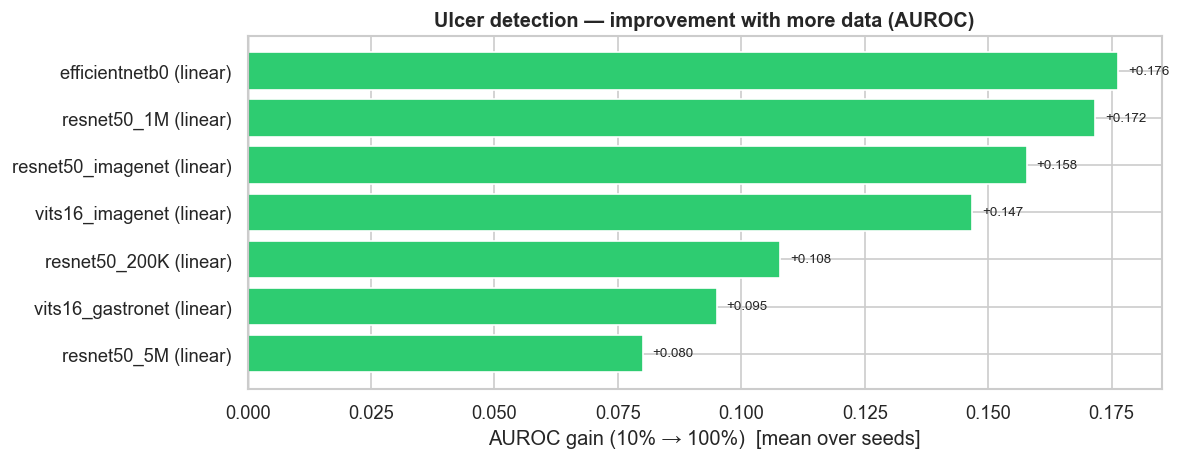

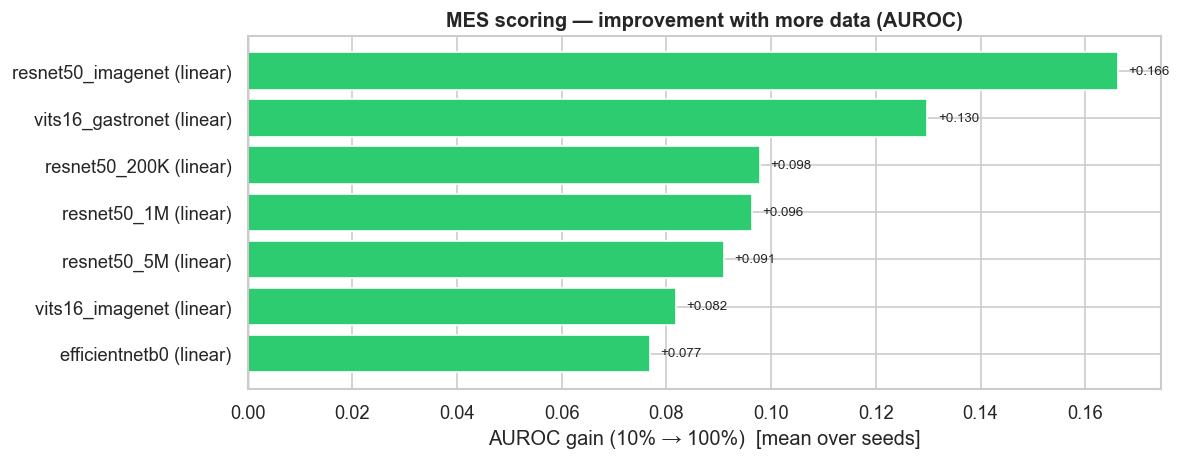

In [24]:
def plot_relative_gain(
    df: pd.DataFrame,
    task: str,
    metric: str = "auroc",
    baseline_ratio: float = 0.10,
    model_filter: list[str] | None = None,
) -> None:
    if df is None:
        return

    if model_filter:
        df = df[df["model"].isin(model_filter)]

    mean_col = f"{metric}_mean"
    if mean_col not in df.columns:
        return

    results = []
    for (model, head), grp in df.groupby(["model", "head_type"]):
        grp = grp.sort_values("subset_ratio")
        baseline_row = grp[grp["subset_ratio"].round(2) == round(baseline_ratio, 2)]
        full_row     = grp[grp["subset_ratio"] == grp["subset_ratio"].max()]
        if baseline_row.empty or full_row.empty:
            continue
        baseline_val = baseline_row[mean_col].values[0]
        full_val     = full_row[mean_col].values[0]
        results.append({"model": model, "head_type": head,
                        "baseline": baseline_val, "full": full_val,
                        "gain": full_val - baseline_val})

    if not results:
        print(f"[{task}] Could not compute relative gains (check subset ratios).")
        return

    rdf    = pd.DataFrame(results).sort_values("gain", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, len(rdf) * 0.5)))
    colors = ["#2ecc71" if g > 0 else "#e74c3c" for g in rdf["gain"]]
    bars   = ax.barh(rdf["model"] + " (" + rdf["head_type"] + ")", rdf["gain"], color=colors)
    for bar, row in zip(bars, rdf.itertuples()):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f"+{row.gain:.3f}", va="center", fontsize=8)
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_xlabel(f"{metric.upper()} gain ({int(baseline_ratio*100)}% → 100%)  [mean over seeds]")
    ax.set_title(f"{task} — improvement with more data ({metric.upper()})", fontweight="bold")
    fig.tight_layout()
    plt.show()

plot_relative_gain(df_ulcer, "Ulcer detection", metric="auroc", model_filter=MODEL_FILTER)
plot_relative_gain(df_mes,   "MES scoring",     metric="auroc", model_filter=MODEL_FILTER)

## 5. Ulcer vs MES Side-by-Side (if both available)

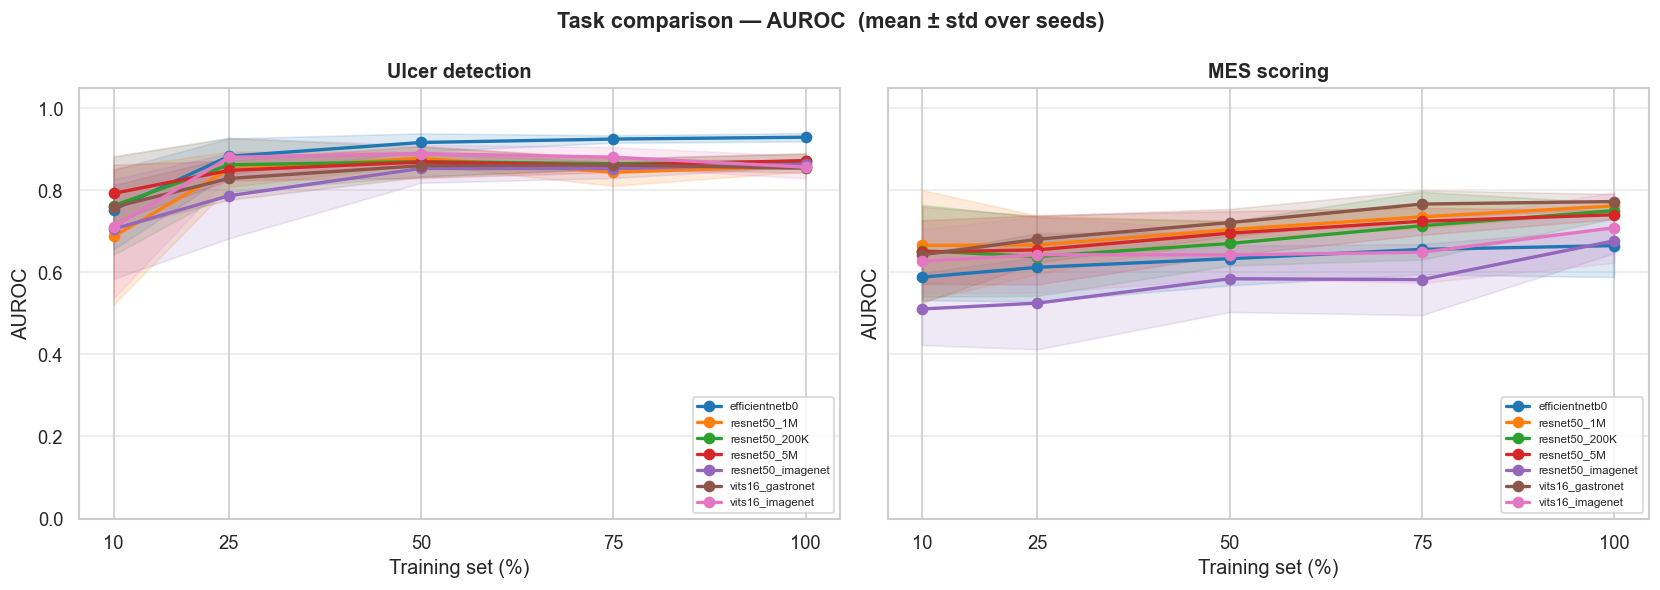

In [25]:
def plot_task_comparison(
    df_a: pd.DataFrame, label_a: str,
    df_b: pd.DataFrame, label_b: str,
    metric: str = "auroc",
    head_filter: list[str] | None = None,
    model_filter: list[str] | None = None,
) -> None:
    if df_a is None or df_b is None:
        print("Both task results needed for comparison.")
        return

    mean_col = f"{metric}_mean"
    std_col  = f"{metric}_std"

    fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.suptitle(
        f"Task comparison — {metric.upper()}  (mean ± std over seeds)",
        fontsize=13, fontweight="bold",
    )

    colors = plt.get_cmap("tab10").colors

    for ax, df, label in [(ax_a, df_a, label_a), (ax_b, df_b, label_b)]:
        if head_filter:
            df = df[df["head_type"].isin(head_filter)]
        if model_filter:
            df = df[df["model"].isin(model_filter)]
        if mean_col not in df.columns:
            continue
        models    = df["model"].unique()
        color_map = {m: colors[i % len(colors)] for i, m in enumerate(models)}

        for model_name, grp in df.groupby("model"):
            grp   = grp.sort_values("subset_ratio")
            x     = grp["subset_ratio"] * 100
            y     = grp[mean_col]
            y_std = grp[std_col] if std_col in grp.columns else 0
            color = color_map[model_name]
            ax.plot(x, y, marker="o", label=model_name, linewidth=2, color=color)
            ax.fill_between(x, y - y_std, y + y_std, color=color, alpha=0.15)

        ax.set_title(label, fontweight="bold")
        ax.set_xlabel("Training set (%)")
        ax.set_ylabel(metric.upper())
        ax.set_ylim(0, 1.05)
        ax.set_xticks([10, 25, 50, 75, 100])
        ax.grid(axis="y", alpha=0.4)
        ax.legend(loc="lower right", fontsize=7)

    fig.tight_layout()
    plt.show()

plot_task_comparison(df_ulcer, "Ulcer detection", df_mes, "MES scoring",
                     metric="auroc", head_filter=HEAD_FILTER, model_filter=MODEL_FILTER)

## 6. Clinical Metrics

Threshold-tuned clinical metrics plotted against training set size:

- **Ulcer detection**: sensitivity, specificity, F1 at the operating point tuned on the validation set
- **MES scoring**: clinical sensitivity (active disease vs remission), specificity, F1

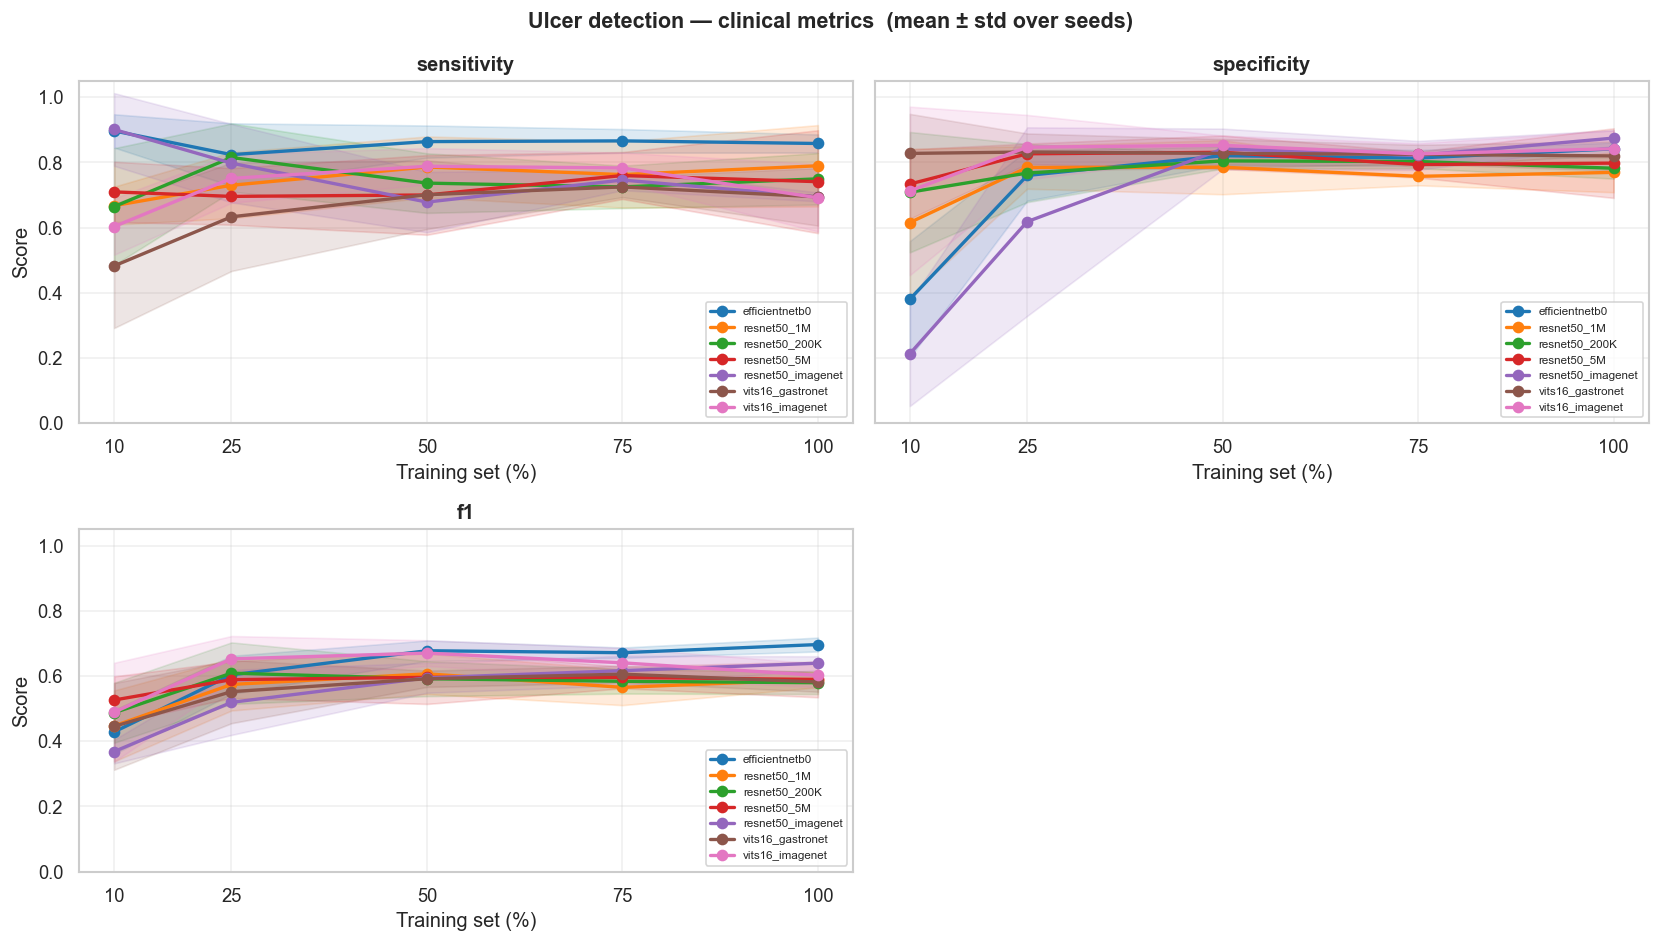

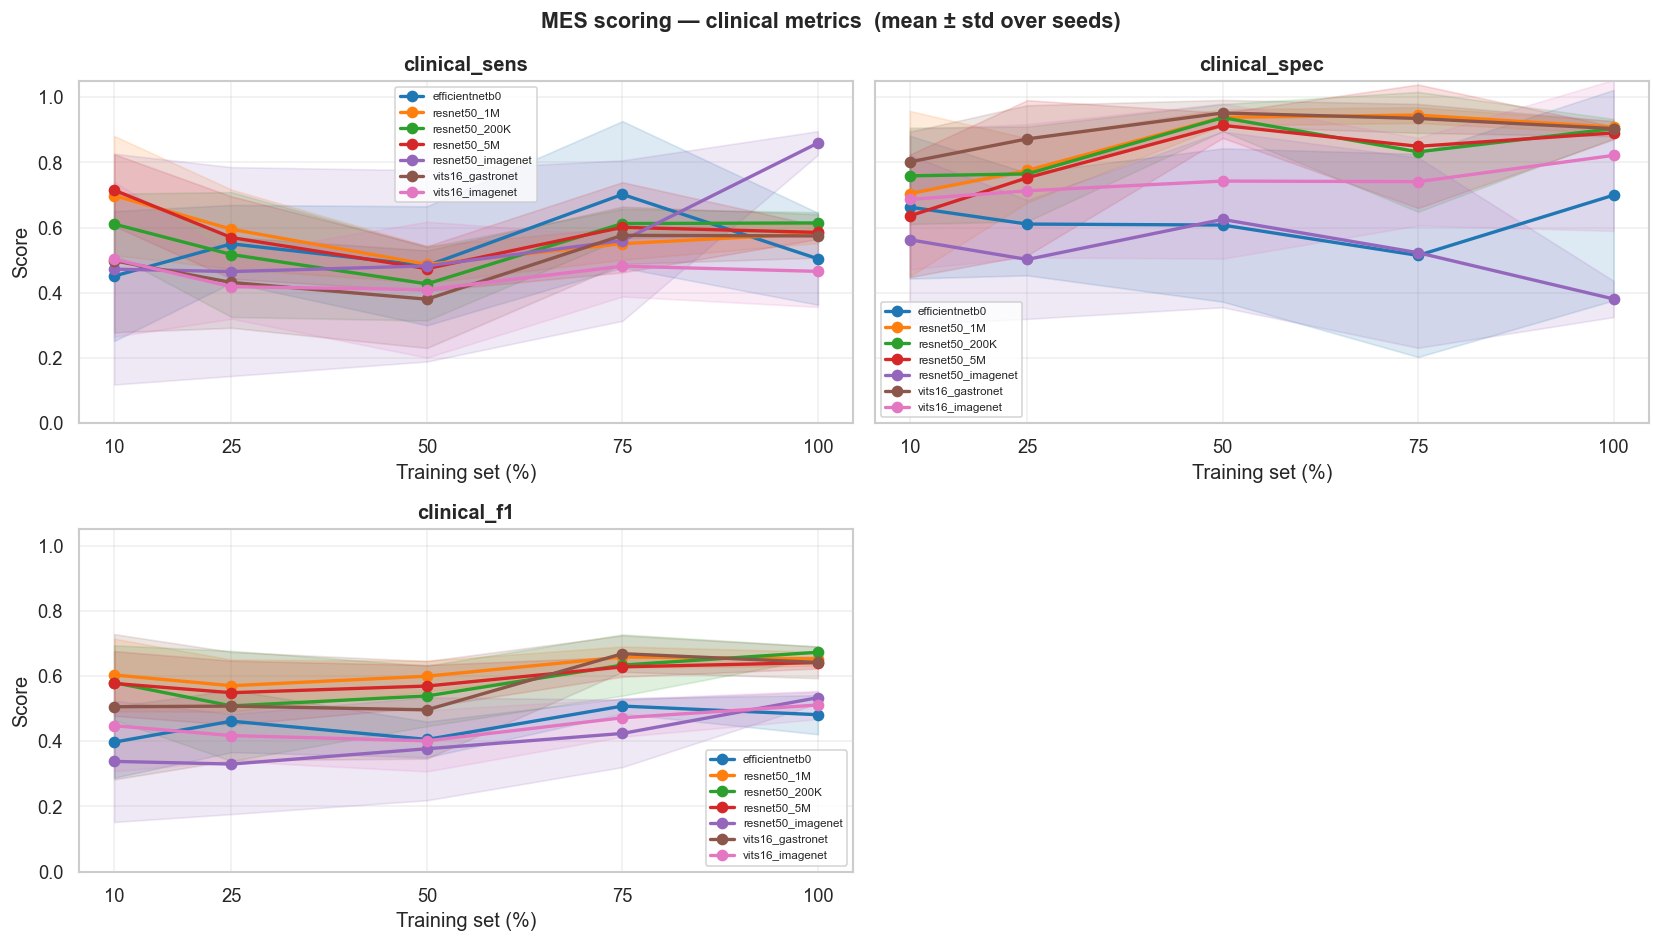

In [26]:
def plot_clinical_metrics(
    df: pd.DataFrame,
    task: str,
    model_filter: list[str] | None = None,
) -> None:
    """Plot clinical metrics vs training set size for ulcer or MES."""
    if df is None:
        return

    if model_filter:
        df = df[df["model"].isin(model_filter)]

    # Ulcer: tuned_sensitivity_mean, tuned_specificity_mean, tuned_f1_mean
    # MES:   cli_sens_mean, cli_spec_mean, cli_f1_mean, macro_f1_mean
    clinical_cols = [
        c for c in df.columns
        if c.endswith("_mean") and any(
            k in c for k in ("cli_", "tuned_sensitivity", "tuned_specificity", "tuned_f1")
        )
    ]
    if not clinical_cols:
        print(f"[{task}] No clinical metric columns found.")
        return

    ncols = min(len(clinical_cols), 2)
    nrows = (len(clinical_cols) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(7 * ncols, 4 * nrows), sharey=True, squeeze=False)
    fig.suptitle(
        f"{task} — clinical metrics  (mean ± std over seeds)",
        fontsize=13, fontweight="bold",
    )

    colors    = plt.get_cmap("tab10").colors
    models    = df["model"].unique()
    color_map = {m: colors[i % len(colors)] for i, m in enumerate(models)}

    for idx, col in enumerate(clinical_cols):
        ax      = axes[idx // ncols][idx % ncols]
        std_col = col.replace("_mean", "_std")

        for model_name, grp in df.groupby("model"):
            grp   = grp.sort_values("subset_ratio")
            x     = grp["subset_ratio"] * 100
            y     = grp[col]
            y_std = grp[std_col] if std_col in grp.columns else 0
            color = color_map[model_name]
            ax.plot(x, y, marker="o", label=model_name, linewidth=2, color=color)
            ax.fill_between(x, y - y_std, y + y_std, color=color, alpha=0.15)

        label = (col.replace("_mean", "")
                   .replace("cli_", "clinical_")
                   .replace("tuned_", ""))
        ax.set_title(label, fontweight="bold")
        ax.set_xlabel("Training set (%)")
        ax.set_ylabel("Score" if idx % ncols == 0 else "")
        ax.set_ylim(0, 1.05)
        ax.set_xticks([10, 25, 50, 75, 100])
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7)

    for idx in range(len(clinical_cols), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.tight_layout()
    plt.show()


plot_clinical_metrics(df_ulcer, "Ulcer detection", MODEL_FILTER)
plot_clinical_metrics(df_mes,   "MES scoring",     MODEL_FILTER)

## 7. Statistical Comparison — Mixed Linear Model

Pairwise comparison of selected models, each at a configurable training fraction.

**Formula** : `response ~ C(run) + C(seed) + (1 | image_id)`

where `run = model_pctpct` (e.g. `vits16_gastronet_100pct`).

- Random intercept **per image** controls for frame-level difficulty (verified: same 1 108 test images across all seeds and fractions).
- `C(seed)` fixed covariate absorbs seed-level variance.
- Response = per-sample Brier score `(truth − P(true class))²` — lower is better → `β < 0` means the challenger performs better than the baseline.
- **Multiple comparison correction** (`STAT_MC_CORRECTION`): `"fdr_bh"` (Benjamini-Hochberg), `"bonferroni"`, `"holm"`, or `None`.
- Baseline and each challenger are `(model, pct)` tuples — you can mix fractions freely.

> Adapted from `Ulcers_detection/src/evaluation/statistical_models_comp.py`


[Ulcer detection] 15 challengers vs baseline=resnet50_imagenet_100pct
  106,368 rows | 1,108 images | 6 seeds | 16 runs
  Formula: diff_squared ~ C(run, Treatment(reference='resnet50_imagenet_100pct')) + C(seed)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                                           Mixed Linear Model Regression Results
===========================================================================================================================
Model:                                   MixedLM                      Dependent Variable:                      diff_squared
No. Observations:                        106368                       Method:                                  ML          
No. Groups:                              1108                         Scale:                                   0.0295      
Min. group size:                         96                           Log-Likelihood:                          33618.3734  
Max. group size:                         96                           Converged:                               Yes         
Mean group size:                         96.0                                                                              
---------------------------------------------------------------------------------------------------------------------------
                                                                                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                                                        0.140    0.007  19.361 0.000  0.126  0.154
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_1M_100pct]    0.020    0.003   6.731 0.000  0.014  0.026
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_1M_10pct]     0.053    0.003  17.707 0.000  0.047  0.059
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_1M_25pct]     0.023    0.003   7.743 0.000  0.017  0.029
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_1M_50pct]     0.008    0.003   2.566 0.010  0.002  0.013
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_1M_75pct]     0.038    0.003  12.683 0.000  0.032  0.044
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_200K_100pct]  0.035    0.003  11.839 0.000  0.029  0.041
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_200K_10pct]   0.041    0.003  13.634 0.000  0.035  0.046
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_200K_25pct]   0.025    0.003   8.237 0.000  0.019  0.030
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_200K_50pct]   0.005    0.003   1.719 0.086 -0.001  0.011
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_200K_75pct]   0.024    0.003   7.965 0.000  0.018  0.030
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_5M_100pct]    0.017    0.003   5.636 0.000  0.011  0.023
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_5M_10pct]     0.037    0.003  12.443 0.000  0.031  0.043
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_5M_25pct]     0.022    0.003   7.260 0.000  0.016  0.027
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_5M_50pct]     0.022    0.003   7.476 0.000  0.016  0.028
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_5M_75pct]     0.023    0.003   7.757 0.000  0.017  0.029
C(seed)[T.256]                                                                   0.009    0.002   4.799 0.000  0.005  0.012
C(seed)[T.364]                                                                  -0.036    0.002 -19.481 0.000 -0.039 -0.032
C(seed)[T.42]                                                                   -0.017    0.002  -9.079 0.000 -0.020 -0.013
C(seed)[T.420]                                                                  -0.032    0.002 -17.768 0.000 -0.036 -0.029
C(seed)[T.84]                                                                   -0.022    0.002 -11.881 0.000 -0.025 -0.018
Group Var                 


Ulcer detection — Mixed LM  [diff_squared ~ C(run) + C(seed) + (1|id)]
Baseline: resnet50_imagenet_100pct   α=0.05 (fdr_bh)
AIC=-67191   BIC=-66971


,challenger,β,95% CI,p_raw,p_fdr_bh,sig,vs baseline
0,resnet50_1M_100pct,0.02005,"[+0.01421, +0.02589]",0.0000,0.0000,***,worse ↑
1,resnet50_1M_10pct,0.05275,"[+0.04691, +0.05859]",0.0000,0.0000,***,worse ↑
2,resnet50_1M_25pct,0.02307,"[+0.01723, +0.02890]",0.0000,0.0000,***,worse ↑
3,resnet50_1M_50pct,0.00764,"[+0.00181, +0.01348]",0.0103,0.0110,*,worse ↑
4,resnet50_1M_75pct,0.03778,"[+0.03194, +0.04362]",0.0000,0.0000,***,worse ↑
5,resnet50_200K_100pct,0.03527,"[+0.02943, +0.04111]",0.0000,0.0000,***,worse ↑
6,resnet50_200K_10pct,0.04062,"[+0.03478, +0.04646]",0.0000,0.0000,***,worse ↑
7,resnet50_200K_25pct,0.02454,"[+0.01870, +0.03038]",0.0000,0.0000,***,worse ↑
8,resnet50_200K_50pct,0.00512,"[-0.00072, +0.01096]",0.0857,0.0857,n.s.,—
9,resnet50_200K_75pct,0.02373,"[+0.01789, +0.02957]",0.0000,0.0000,***,worse ↑


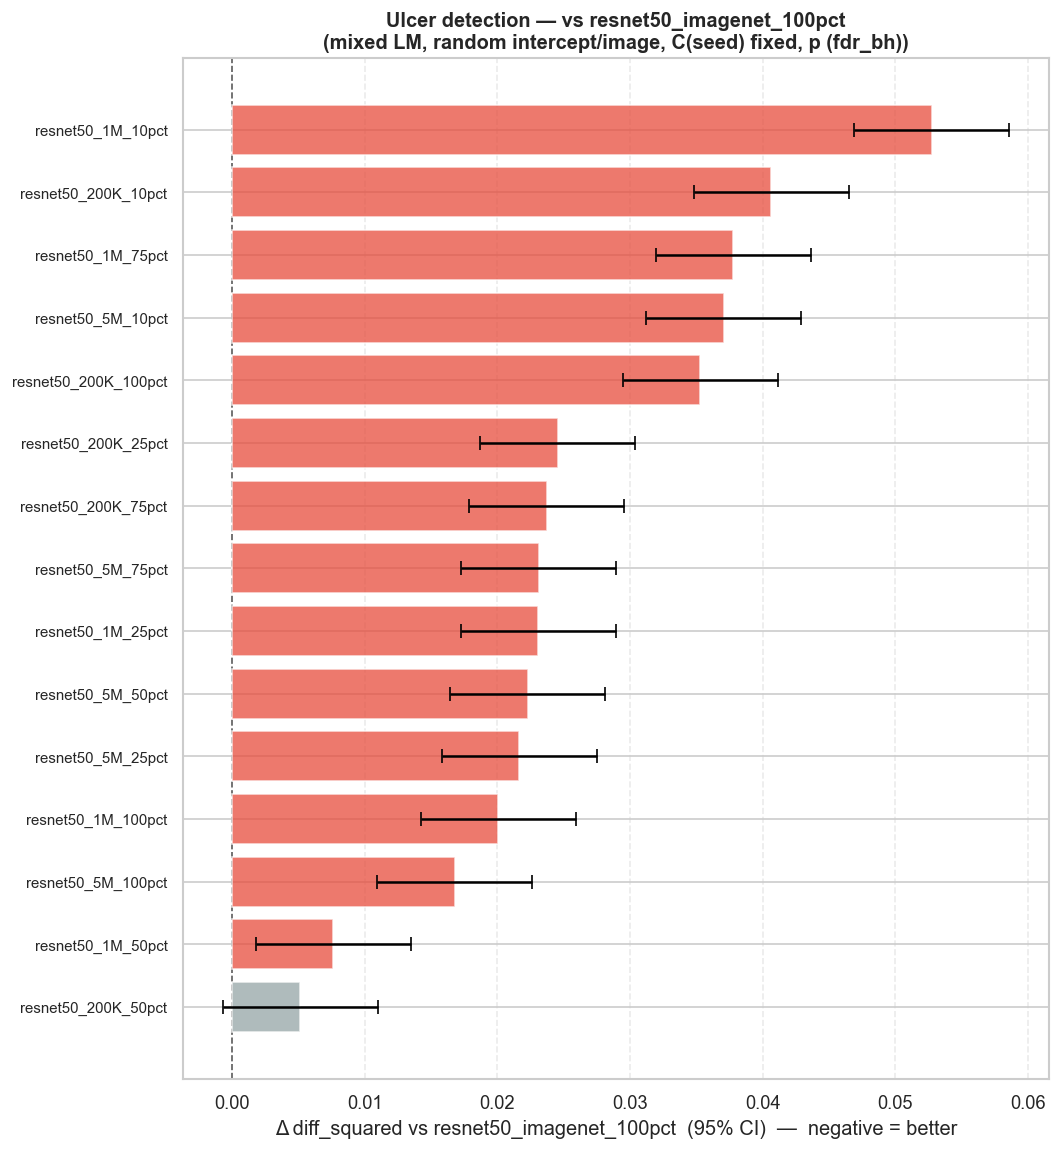


[MES scoring] 15 challengers vs baseline=resnet50_imagenet_100pct
  164,640 rows | 1,715 images | 6 seeds | 16 runs
  Formula: diff_squared ~ C(run, Treatment(reference='resnet50_imagenet_100pct')) + C(seed)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                                           Mixed Linear Model Regression Results
===========================================================================================================================
Model:                                   MixedLM                      Dependent Variable:                      diff_squared
No. Observations:                        164640                       Method:                                  ML          
No. Groups:                              1715                         Scale:                                   0.0660      
Min. group size:                         96                           Log-Likelihood:                          -14144.1284 
Max. group size:                         96                           Converged:                               Yes         
Mean group size:                         96.0                                                                              
---------------------------------------------------------------------------------------------------------------------------
                                                                                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                                                        0.554    0.008  68.424 0.000  0.538  0.570
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_1M_100pct]   -0.202    0.004 -56.409 0.000 -0.209 -0.195
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_1M_10pct]    -0.122    0.004 -33.948 0.000 -0.129 -0.115
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_1M_25pct]    -0.135    0.004 -37.719 0.000 -0.142 -0.128
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_1M_50pct]    -0.182    0.004 -50.824 0.000 -0.189 -0.175
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_1M_75pct]    -0.194    0.004 -54.265 0.000 -0.201 -0.187
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_200K_100pct] -0.212    0.004 -59.251 0.000 -0.219 -0.205
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_200K_10pct]  -0.099    0.004 -27.593 0.000 -0.106 -0.092
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_200K_25pct]  -0.099    0.004 -27.570 0.000 -0.106 -0.092
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_200K_50pct]  -0.167    0.004 -46.499 0.000 -0.174 -0.160
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_200K_75pct]  -0.166    0.004 -46.324 0.000 -0.173 -0.159
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_5M_100pct]   -0.204    0.004 -57.075 0.000 -0.211 -0.197
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_5M_10pct]    -0.085    0.004 -23.811 0.000 -0.092 -0.078
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_5M_25pct]    -0.132    0.004 -36.875 0.000 -0.139 -0.125
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_5M_50pct]    -0.179    0.004 -49.994 0.000 -0.186 -0.172
C(run, Treatment(reference='resnet50_imagenet_100pct'))[T.resnet50_5M_75pct]    -0.170    0.004 -47.522 0.000 -0.177 -0.163
C(seed)[T.256]                                                                  -0.023    0.002 -10.503 0.000 -0.027 -0.019
C(seed)[T.364]                                                                  -0.033    0.002 -15.262 0.000 -0.038 -0.029
C(seed)[T.42]                                                                   -0.019    0.002  -8.454 0.000 -0.023 -0.014
C(seed)[T.420]                                                                   0.004    0.002   1.952 0.051 -0.000  0.009
C(seed)[T.84]                                                                   -0.002    0.002  -1.116 0.264 -0.007  0.002
Group Var                 


MES scoring — Mixed LM  [diff_squared ~ C(run) + C(seed) + (1|id)]
Baseline: resnet50_imagenet_100pct   α=0.05 (fdr_bh)
AIC=28334   BIC=28565


,challenger,β,95% CI,p_raw,p_fdr_bh,sig,vs baseline
0,resnet50_1M_100pct,-0.20207,"[-0.20909, -0.19505]",0.0,0.0,***,better ↓
1,resnet50_1M_10pct,-0.12161,"[-0.12863, -0.11459]",0.0,0.0,***,better ↓
2,resnet50_1M_25pct,-0.13512,"[-0.14214, -0.12810]",0.0,0.0,***,better ↓
3,resnet50_1M_50pct,-0.18206,"[-0.18908, -0.17504]",0.0,0.0,***,better ↓
4,resnet50_1M_75pct,-0.19439,"[-0.20141, -0.18736]",0.0,0.0,***,better ↓
5,resnet50_200K_100pct,-0.21225,"[-0.21927, -0.20523]",0.0,0.0,***,better ↓
6,resnet50_200K_10pct,-0.09884,"[-0.10587, -0.09182]",0.0,0.0,***,better ↓
7,resnet50_200K_25pct,-0.09876,"[-0.10578, -0.09174]",0.0,0.0,***,better ↓
8,resnet50_200K_50pct,-0.16657,"[-0.17359, -0.15955]",0.0,0.0,***,better ↓
9,resnet50_200K_75pct,-0.16594,"[-0.17296, -0.15892]",0.0,0.0,***,better ↓


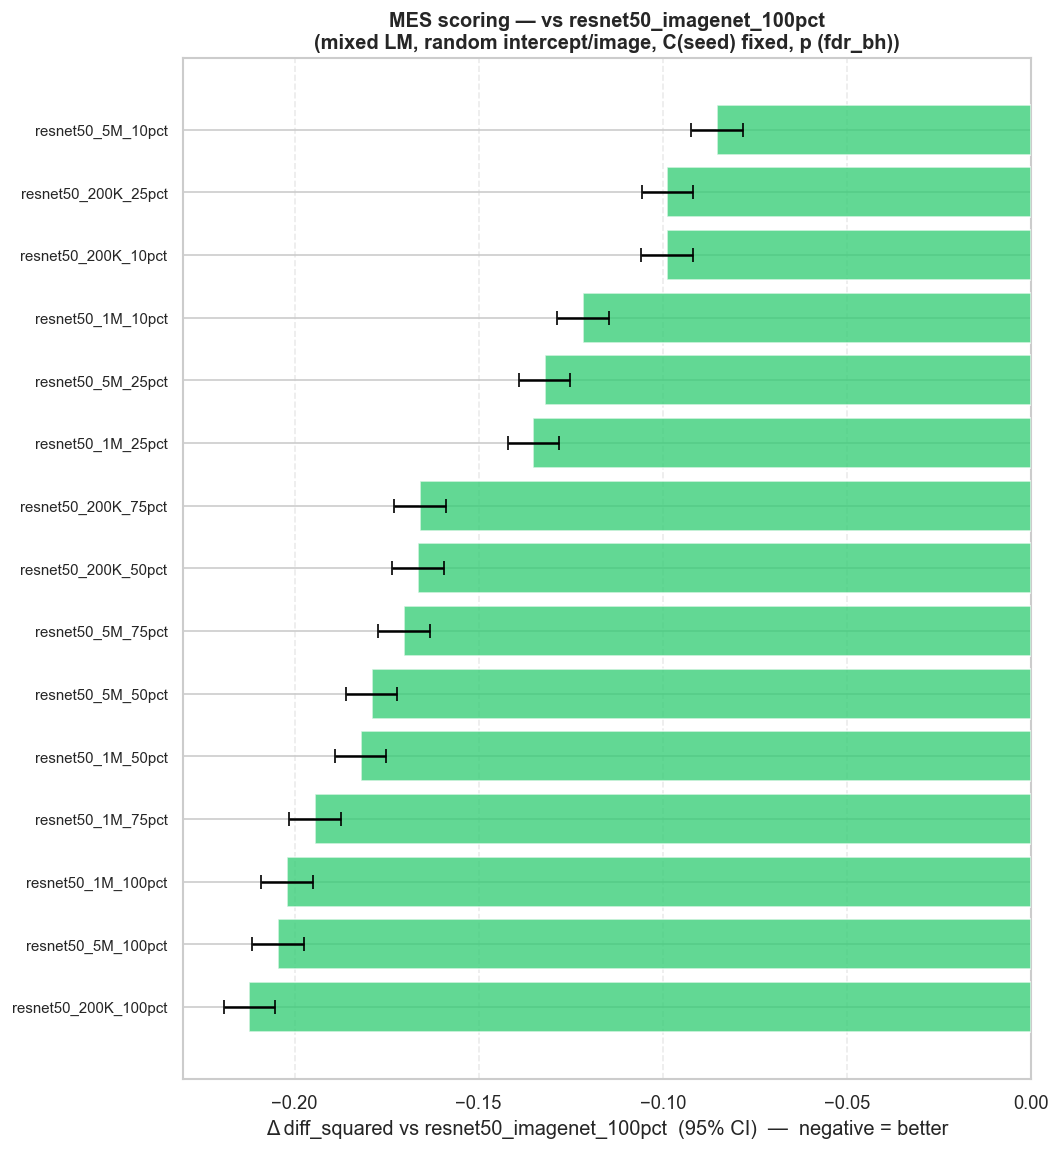

In [27]:
import re
import warnings
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

# ── Paths ──────────────────────────────────────────────────────────────────────
ULCER_PREDS    = ROOT / "results/ulcer/data_efficiency/predictions"
ULCER_MANIFEST = ROOT / "data/ulcer/splits/dataset_manifest.csv"
MES_PREDS      = ROOT / "results/mes/data_efficiency/predictions"
MES_MANIFEST   = ROOT / "data/mes/splits/dataset_manifest.csv"

# ── Config ─────────────────────────────────────────────────────────────────────
TARGET_PCT    = 100             # fallback pct when baseline / challengers are None
STAT_HEAD     = "linear"
STAT_ALPHA    = 0.05
STAT_RESPONSE = "diff_squared"  # "diff_squared" (Brier) | "log_loss"

# Multiple comparison correction: "fdr_bh" | "bonferroni" | "holm" | None
STAT_MC_CORRECTION = "fdr_bh"

# Baseline: (model_name, pct) — None → auto (lowest mean Brier at TARGET_PCT)
STAT_BASELINE: tuple[str, int] | None = "resnet50_imagenet", 100

# Challengers: list of (model_name, pct) — None → all models except baseline at TARGET_PCT
STAT_CHALLENGERS: list[tuple[str, int]] | None = [
    ("resnet50_5M", 10), ("resnet50_5M", 25), ("resnet50_5M", 50), ("resnet50_5M", 75), ("resnet50_5M", 100),
    ("resnet50_1M", 10), ("resnet50_1M", 25), ("resnet50_1M", 50), ("resnet50_1M", 75), ("resnet50_1M", 100),
    ("resnet50_200K", 10), ("resnet50_200K", 25), ("resnet50_200K", 50), ("resnet50_200K", 75), ("resnet50_200K", 100),
]
# Examples:
# STAT_BASELINE    = ("vits16_gastronet", 100)
# STAT_CHALLENGERS = [("resnet50_5M", 100), ("vits16_imagenet", 50)]


# ── Helpers ────────────────────────────────────────────────────────────────────

_RUN_PAT = re.compile(
    r"^(?P<model>.+?)_(?P<freeze>finetune|frozen)_(?P<head>\w+)_"
    r"(?P<pct>\d+)pct_seed(?P<seed>\d+)$"
)


def _discover_at_pct(preds_dir: Path, head_filter: str, pct: int) -> list[str]:
    return sorted({
        m.group("model")
        for d in preds_dir.iterdir() if d.is_dir()
        for m in [_RUN_PAT.match(d.name)]
        if m and m.group("head") == head_filter and int(m.group("pct")) == pct
    })


def load_runs_df(
    preds_dir: Path,
    manifest_path: Path,
    runs: list[tuple[str, int]],
    head_filter: str,
) -> pd.DataFrame:
    """Per-sample DataFrame for specified (model, pct) pairs across all seeds."""
    manifest = pd.read_csv(manifest_path)
    test_ids = manifest[manifest["split"] == "test"]["filepath"].tolist()
    n_test   = len(test_ids)
    target   = {(model, pct) for model, pct in runs}

    rows = []
    for run_dir in sorted(preds_dir.iterdir()):
        if not run_dir.is_dir():
            continue
        m = _RUN_PAT.match(run_dir.name)
        if m is None or m.group("head") != head_filter:
            continue
        model, pct = m.group("model"), int(m.group("pct"))
        if (model, pct) not in target:
            continue

        labels = np.load(run_dir / "test_labels.npy")
        probs  = np.load(run_dir / "test_probs.npy")
        if len(labels) != n_test:
            continue

        seed      = str(m.group("seed"))
        run_label = f"{model}_{pct}pct"

        if probs.ndim == 2:
            pred  = probs[np.arange(len(labels)), labels].astype(float)
            truth = np.ones(len(labels), dtype=float)
        else:
            pred  = probs.astype(float)
            truth = labels.astype(float)

        pred_c = np.clip(pred, 1e-7, 1 - 1e-7)
        diff   = truth - pred_c
        for img_id, d, t in zip(test_ids, diff, truth):
            rows.append({
                "id":           img_id,
                "run":          run_label,
                "seed":         seed,
                "diff_squared": float(d * d),
                "log_loss":     float(-t * np.log(np.clip(t - d, 1e-7, 1 - 1e-7))),
            })
    return pd.DataFrame(rows)


# ── Mixed model ────────────────────────────────────────────────────────────────

def run_mixed_model(
    preds_dir: Path,
    manifest_path: Path,
    task: str,
    target_pct: int = 100,
    response: str = "diff_squared",
    head_filter: str = "linear",
    baseline: tuple[str, int] | None = None,
    challengers: list[tuple[str, int]] | None = None,
    mc_correction: str | None = "fdr_bh",
    alpha: float = 0.05,
) -> None:
    """
    Mixed LM comparing (model, pct) runs:
        response ~ C(run, Treatment(baseline)) + C(seed) + (1 | image_id)

    β < 0 → challenger has less error → better than baseline.
    """
    if not preds_dir.exists():
        print(f"[{task}] Predictions dir not found: {preds_dir}")
        return

    # Resolve baseline
    if baseline is None:
        avail = _discover_at_pct(preds_dir, head_filter, target_pct)
        if not avail:
            print(f"[{task}] No runs at {target_pct}% with head={head_filter}.")
            return
        df_disc = load_runs_df(preds_dir, manifest_path,
                               [(m, target_pct) for m in avail], head_filter)
        best_run = str(df_disc.groupby("run")[response].mean().idxmin())
        baseline = (best_run.replace(f"_{target_pct}pct", ""), target_pct)
        print(f"[{task}] Auto-baseline: {baseline[0]} @ {baseline[1]}%")

    baseline_label = f"{baseline[0]}_{baseline[1]}pct"

    # Resolve challengers
    if challengers is None:
        avail = _discover_at_pct(preds_dir, head_filter, target_pct)
        challengers = [
            (m, target_pct) for m in avail
            if not (m == baseline[0] and target_pct == baseline[1])
        ]

    if not challengers:
        print(f"[{task}] No challenger runs to compare.")
        return

    all_runs = [baseline] + challengers
    print(f"\n[{task}] {len(challengers)} challengers vs baseline={baseline_label}")
    df = load_runs_df(preds_dir, manifest_path, all_runs, head_filter)

    found_runs = df["run"].unique().tolist()
    missing = [f"{m}_{p}pct" for m, p in all_runs if f"{m}_{p}pct" not in found_runs]
    if missing:
        print(f"  Warning — runs not found: {missing}")

    print(f"  {len(df):,} rows | {df['id'].nunique():,} images | "
          f"{df['seed'].nunique()} seeds | {len(found_runs)} runs")

    formula = (
        f"{response} ~ "
        f"C(run, Treatment(reference='{baseline_label}')) + C(seed)"
    )
    print(f"  Formula: {formula}")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit = smf.mixedlm(formula, df, groups=df["id"]).fit(reml=False)

    params, pvals, ci = fit.params, fit.pvalues, fit.conf_int()

    display(fit.summary())

    # Extract challenger terms (model effects only, no interactions)
    chall_terms = [
        (p, float(params[p]), float(pvals[p]), float(ci.loc[p, 0]), float(ci.loc[p, 1]))
        for p in params.index
        if "C(run" in p and ":" not in p
    ]
    if not chall_terms:
        print(f"[{task}] No challenger parameters in model output.")
        return

    # Multiple comparison correction
    raw_pvals = np.array([pv for _, _, pv, _, _ in chall_terms])
    if mc_correction and len(raw_pvals) > 1:
        _, p_adj, _, _ = multipletests(raw_pvals, alpha=alpha, method=mc_correction)
        p_col = f"p_{mc_correction}"
    else:
        p_adj = raw_pvals.copy()
        p_col = "p"

    mc_note = f" ({mc_correction})" if mc_correction else " (uncorrected)"

    rows = []
    for (p, b, pv_raw, lo, hi), pv_adj in zip(chall_terms, p_adj):
        label   = p.split("[T.")[-1].rstrip("]") if "[T." in p else p
        sig     = ("***" if pv_adj < 0.001 else "**" if pv_adj < 0.01
                   else "*" if pv_adj < alpha else "n.s.")
        verdict = ("better ↓" if (pv_adj < alpha and b < 0)
                   else "worse  ↑" if (pv_adj < alpha and b > 0) else "—")
        rows.append({
            "challenger":  label,
            "β":           round(b, 5),
            "95% CI":      f"[{lo:+.5f}, {hi:+.5f}]",
            "p_raw":       round(pv_raw, 4),
            p_col:         round(float(pv_adj), 4),
            "sig":         sig,
            "vs baseline": verdict,
        })

    print(f"\n{'='*72}")
    print(f"{task} — Mixed LM  [{response} ~ C(run) + C(seed) + (1|id)]")
    print(f"Baseline: {baseline_label}   α={alpha}{mc_note}")
    print(f"AIC={fit.aic:.0f}   BIC={fit.bic:.0f}")
    print(f"{'='*72}")
    display(pd.DataFrame(rows))

    # Forest plot
    df_eff = pd.DataFrame(rows).sort_values("β")
    ci_lo  = df_eff["95% CI"].str.extract(r"\[([^,]+),")[0].astype(float).values
    ci_hi  = df_eff["95% CI"].str.extract(r",\s*([^\]]+)\]")[0].astype(float).values
    betas  = df_eff["β"].values
    clr    = {"better ↓": "#2ecc71", "worse  ↑": "#e74c3c", "—": "#95a5a6"}
    colors = [clr.get(v, "#95a5a6") for v in df_eff["vs baseline"]]

    fig, ax = plt.subplots(figsize=(9, max(3, len(df_eff) * 0.55 + 1.5)))
    y = np.arange(len(df_eff))
    ax.barh(y, betas, color=colors, alpha=0.75, zorder=3)
    ax.errorbar(betas, y, xerr=[betas - ci_lo, ci_hi - betas],
                fmt="none", color="black", capsize=4, linewidth=1.5, zorder=4)
    ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels(df_eff["challenger"].values, fontsize=9)
    ax.set_xlabel(f"Δ {response} vs {baseline_label}  (95% CI)  —  negative = better")
    ax.set_title(
        f"{task} — vs {baseline_label}\n"
        f"(mixed LM, random intercept/image, C(seed) fixed, p{mc_note})",
        fontweight="bold",
    )
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    fig.tight_layout()
    plt.show()


# ── Run ────────────────────────────────────────────────────────────────────────
run_mixed_model(
    ULCER_PREDS, ULCER_MANIFEST, "Ulcer detection",
    target_pct=TARGET_PCT, response=STAT_RESPONSE, head_filter=STAT_HEAD,
    baseline=STAT_BASELINE, challengers=STAT_CHALLENGERS,
    mc_correction=STAT_MC_CORRECTION, alpha=STAT_ALPHA,
)
run_mixed_model(
    MES_PREDS, MES_MANIFEST, "MES scoring",
    target_pct=TARGET_PCT, response=STAT_RESPONSE, head_filter=STAT_HEAD,
    baseline=STAT_BASELINE, challengers=STAT_CHALLENGERS,
    mc_correction=STAT_MC_CORRECTION, alpha=STAT_ALPHA,
)


[Ulcer detection] 5 challengers vs baseline=vits16_imagenet_100pct
  39,888 rows | 1,108 images | 6 seeds | 6 runs
  Formula: diff_squared ~ C(run, Treatment(reference='vits16_imagenet_100pct')) + C(seed)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                                           Mixed Linear Model Regression Results
===========================================================================================================================
Model:                                   MixedLM                      Dependent Variable:                      diff_squared
No. Observations:                        39888                        Method:                                  ML          
No. Groups:                              1108                         Scale:                                   0.0559      
Min. group size:                         36                           Log-Likelihood:                          -1204.7069  
Max. group size:                         36                           Converged:                               Yes         
Mean group size:                         36.0                                                                              
---------------------------------------------------------------------------------------------------------------------------
                                                                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                                                         0.168    0.009 18.890 0.000  0.151  0.186
C(run, Treatment(reference='vits16_imagenet_100pct'))[T.vits16_gastronet_100pct]  0.022    0.004  5.419 0.000  0.014  0.030
C(run, Treatment(reference='vits16_imagenet_100pct'))[T.vits16_gastronet_10pct]   0.038    0.004  9.321 0.000  0.030  0.046
C(run, Treatment(reference='vits16_imagenet_100pct'))[T.vits16_gastronet_25pct]   0.029    0.004  7.134 0.000  0.021  0.037
C(run, Treatment(reference='vits16_imagenet_100pct'))[T.vits16_gastronet_50pct]   0.014    0.004  3.445 0.001  0.006  0.022
C(run, Treatment(reference='vits16_imagenet_100pct'))[T.vits16_gastronet_75pct]   0.015    0.004  3.762 0.000  0.007  0.023
C(seed)[T.256]                                                                   -0.001    0.004 -0.132 0.895 -0.009  0.007
C(seed)[T.364]                                                                   -0.018    0.004 -4.468 0.000 -0.026 -0.010
C(seed)[T.42]                                                                    -0.003    0.004 -0.801 0.423 -0.011  0.005
C(seed)[T.420]                                                                   -0.040    0.004 -9.638 0.000 -0.048 -0.031
C(seed)[T.84]                                                                    -0.021    0.004 -5.033 0.000 -0.029 -0.013
Group Var                                                                         0.071    0.013                           
===========================================================================================================================

"""


Ulcer detection — Mixed LM  [diff_squared ~ C(run) + C(seed) + (1|id)]
Baseline: vits16_imagenet_100pct   α=0.05 (fdr_bh)
AIC=2435   BIC=2547


,challenger,β,95% CI,p_raw,p_fdr_bh,sig,vs baseline
0,vits16_gastronet_100pct,0.02222,"[+0.01419, +0.03026]",0.0000,0.0000,***,worse ↑
1,vits16_gastronet_10pct,0.03822,"[+0.03019, +0.04626]",0.0000,0.0000,***,worse ↑
2,vits16_gastronet_25pct,0.02926,"[+0.02122, +0.03729]",0.0000,0.0000,***,worse ↑
3,vits16_gastronet_50pct,0.01413,"[+0.00609, +0.02217]",0.0006,0.0006,***,worse ↑
4,vits16_gastronet_75pct,0.01543,"[+0.00739, +0.02346]",0.0002,0.0002,***,worse ↑


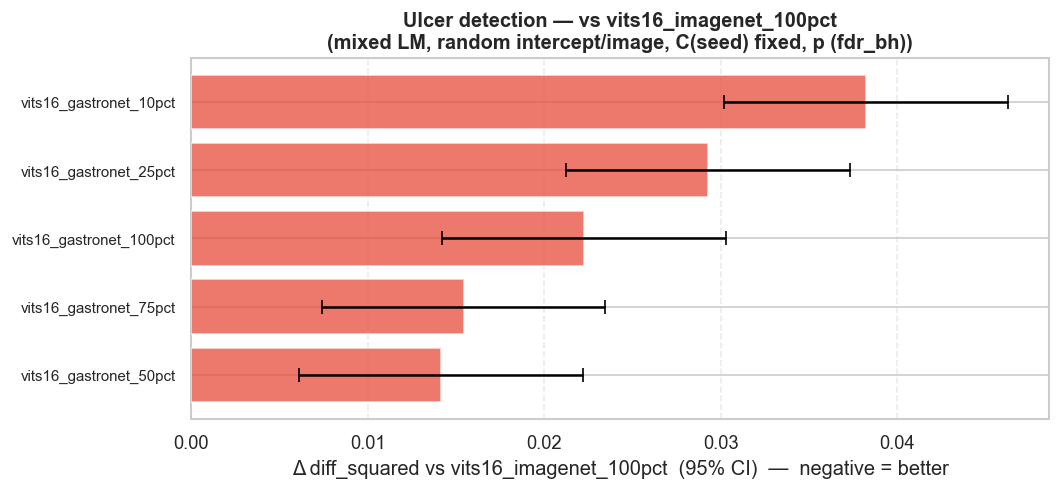


[MES scoring] 5 challengers vs baseline=vits16_imagenet_100pct
  61,740 rows | 1,715 images | 6 seeds | 6 runs
  Formula: diff_squared ~ C(run, Treatment(reference='vits16_imagenet_100pct')) + C(seed)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                                           Mixed Linear Model Regression Results
============================================================================================================================
Model:                                  MixedLM                       Dependent Variable:                       diff_squared
No. Observations:                       61740                         Method:                                   ML          
No. Groups:                             1715                          Scale:                                    0.0767      
Min. group size:                        36                            Log-Likelihood:                           -11922.1409 
Max. group size:                        36                            Converged:                                Yes         
Mean group size:                        36.0                                                                                
----------------------------------------------------------------------------------------------------------------------------
                                                                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------------------------------------------
Intercept                                                                         0.419    0.010  43.064 0.000  0.400  0.438
C(run, Treatment(reference='vits16_imagenet_100pct'))[T.vits16_gastronet_100pct] -0.069    0.004 -17.833 0.000 -0.076 -0.061
C(run, Treatment(reference='vits16_imagenet_100pct'))[T.vits16_gastronet_10pct]   0.023    0.004   5.888 0.000  0.015  0.030
C(run, Treatment(reference='vits16_imagenet_100pct'))[T.vits16_gastronet_25pct]   0.002    0.004   0.571 0.568 -0.005  0.010
C(run, Treatment(reference='vits16_imagenet_100pct'))[T.vits16_gastronet_50pct]  -0.038    0.004  -9.842 0.000 -0.046 -0.030
C(run, Treatment(reference='vits16_imagenet_100pct'))[T.vits16_gastronet_75pct]  -0.064    0.004 -16.584 0.000 -0.072 -0.056
C(seed)[T.256]                                                                   -0.005    0.004  -1.369 0.171 -0.013  0.002
C(seed)[T.364]                                                                    0.007    0.004   1.930 0.054 -0.000  0.015
C(seed)[T.42]                                                                    -0.030    0.004  -7.856 0.000 -0.038 -0.023
C(seed)[T.420]                                                                    0.014    0.004   3.541 0.000  0.006  0.021
C(seed)[T.84]                                                                    -0.002    0.004  -0.561 0.575 -0.010  0.005
Group Var                                                                         0.139    0.018                            
============================================================================================================================

"""


MES scoring — Mixed LM  [diff_squared ~ C(run) + C(seed) + (1|id)]
Baseline: vits16_imagenet_100pct   α=0.05 (fdr_bh)
AIC=23870   BIC=23988


,challenger,β,95% CI,p_raw,p_fdr_bh,sig,vs baseline
0,vits16_gastronet_100pct,-0.06884,"[-0.07641, -0.06128]",0.0000,0.0000,***,better ↓
1,vits16_gastronet_10pct,0.02273,"[+0.01517, +0.03030]",0.0000,0.0000,***,worse ↑
2,vits16_gastronet_25pct,0.00221,"[-0.00536, +0.00977]",0.5677,0.5677,n.s.,—
3,vits16_gastronet_50pct,-0.03799,"[-0.04556, -0.03043]",0.0000,0.0000,***,better ↓
4,vits16_gastronet_75pct,-0.06402,"[-0.07159, -0.05646]",0.0000,0.0000,***,better ↓


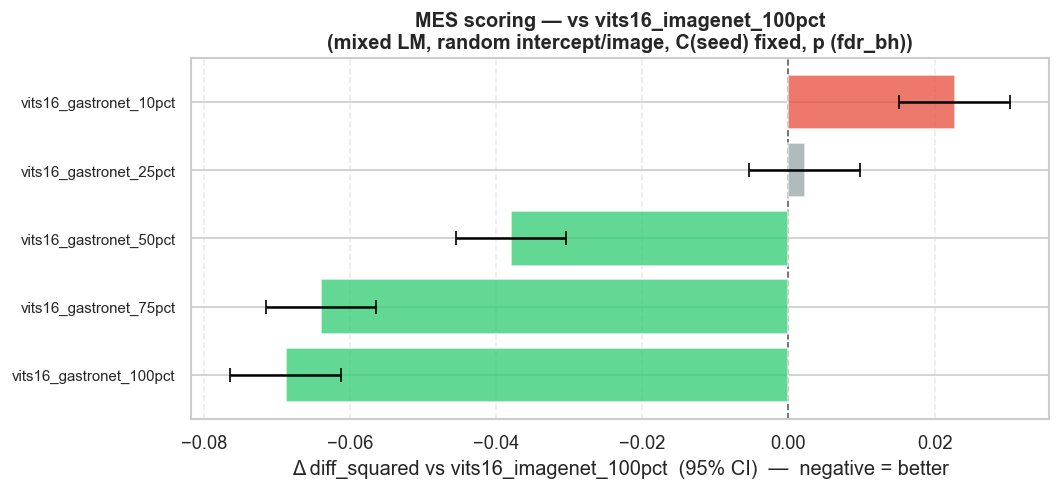

In [28]:
STAT_BASELINE_2 = ("vits16_imagenet", 100)
STAT_CHALLENGERS_2 = [
    ("vits16_gastronet", 10), ("vits16_gastronet", 25), ("vits16_gastronet", 50), ("vits16_gastronet", 75), ("vits16_gastronet", 100),
]

# ── Run ────────────────────────────────────────────────────────────────────────
run_mixed_model(
    ULCER_PREDS, ULCER_MANIFEST, "Ulcer detection",
    target_pct=TARGET_PCT, response=STAT_RESPONSE, head_filter=STAT_HEAD,
    baseline=STAT_BASELINE_2, challengers=STAT_CHALLENGERS_2,
    mc_correction=STAT_MC_CORRECTION, alpha=STAT_ALPHA,
)
run_mixed_model(
    MES_PREDS, MES_MANIFEST, "MES scoring",
    target_pct=TARGET_PCT, response=STAT_RESPONSE, head_filter=STAT_HEAD,
    baseline=STAT_BASELINE_2, challengers=STAT_CHALLENGERS_2,
    mc_correction=STAT_MC_CORRECTION, alpha=STAT_ALPHA,
)